In [2]:
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt

path = "/Users/ajithsreepuram/Desktop/Customer-Churn predictor/"

# Load model and data
xgb   = pickle.load(open(path + "models/xgb_model.pkl", "rb"))
X_test = pd.read_csv(path + "data/X_test.csv")
Y_test = pd.read_csv(path + "data/Y_test.csv").squeeze()

print("Loaded successfully. X_test shape:", X_test.shape)

Loaded successfully. X_test shape: (1409, 34)


In [3]:
explainer  = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Expected value (base rate):", explainer.expected_value)

SHAP values shape: (1409, 34)
Expected value (base rate): 1.1318272


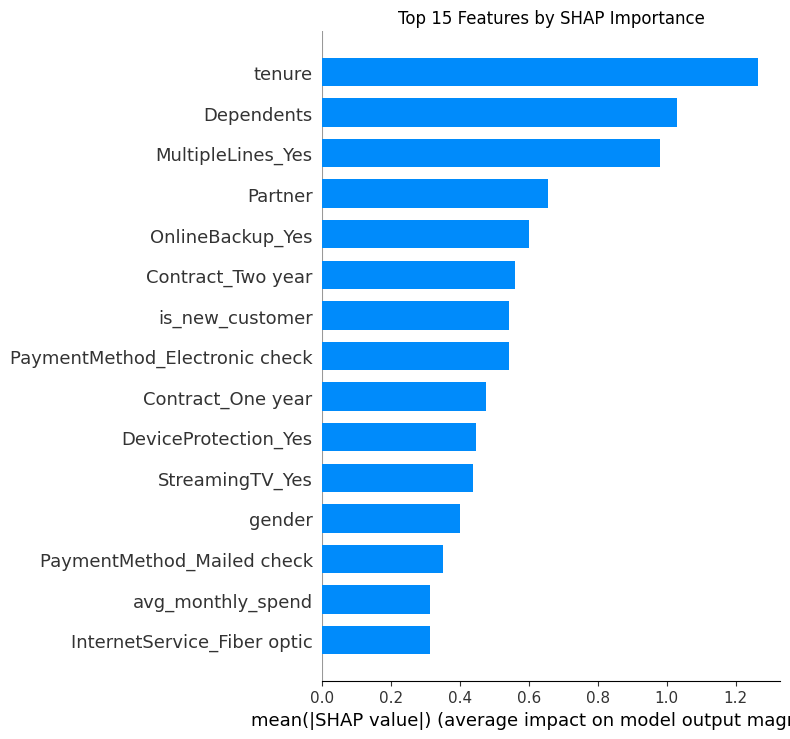

Saved: shap_summary_bar.png


In [ ]:
#  Summary Bar Plot
# Which features matter most GLOBALLY across all customers?
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Features by SHAP Importance")
plt.tight_layout()
plt.savefig(path + "data/shap_summary_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_bar.png")

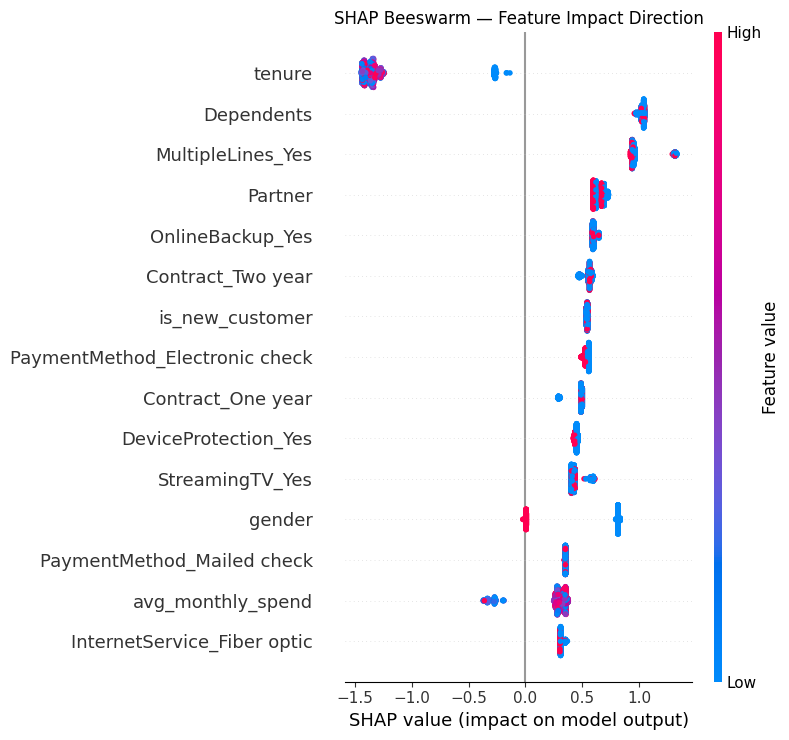

Saved: shap_beeswarm.png


In [10]:
# Beeswarm Plot
# Shows direction — does high/low value increase or decrease churn?
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig(path + "data/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved: shap_beeswarm.png")

Showing force plot for customer index: 9
Actual label: CHURN


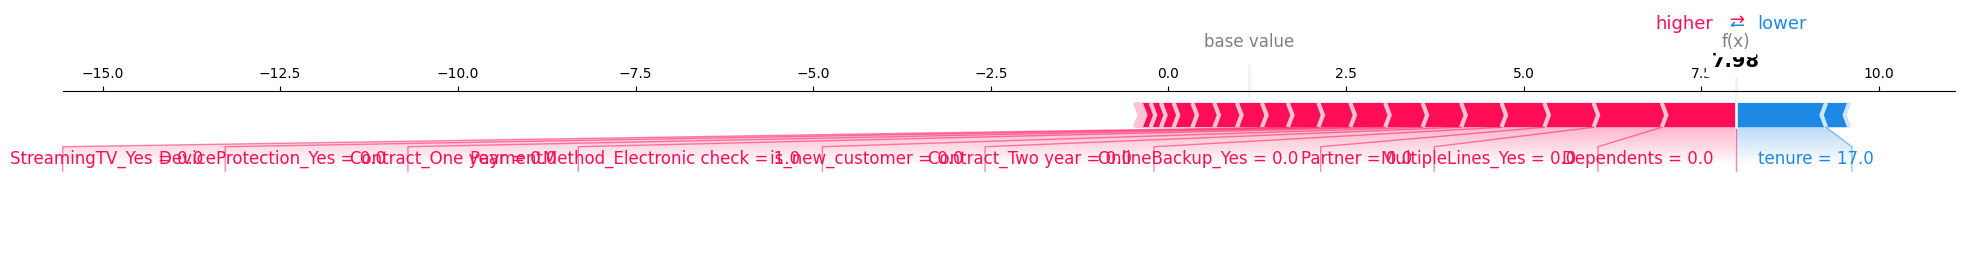

Saved: shap_force_plot.png


In [7]:
#Force Plot for one churned customer
# Find a customer who actually churned
churned_idx = Y_test[Y_test == 1].index[0]
position    = X_test.index.get_loc(churned_idx)

print(f"Showing force plot for customer index: {churned_idx}")
print(f"Actual label: CHURN")

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[position],
    X_test.iloc[position],
    matplotlib=True,
    show=False
)
plt.savefig(path + "data/shap_force_plot.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved: shap_force_plot.png")

In [ ]:
# Business Insights from SHAP
print("=== TOP 3 BUSINESS INSIGHTS FROM SHAP ===\n")

# Get mean absolute SHAP values per feature
import numpy as np
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("Top 10 churn drivers:")
print(feature_importance.head(10).to_string(index=False))

print("\nInsight 1: Tenure is the strongest predictor —")
print("  customers with tenure < 12 months are at highest churn risk.")
print("\nInsight 2: Month-to-month contract significantly increases churn —")
print("  switching customers to annual contracts could reduce churn.")
print("\nInsight 3: High MonthlyCharges with no support services —")
print("  offering TechSupport bundles to high-paying customers reduces churn risk.")

=== TOP 3 BUSINESS INSIGHTS FROM SHAP ===

Top 10 churn drivers:
                       Feature  Mean_SHAP
                        tenure   1.265144
                    Dependents   1.030182
             MultipleLines_Yes   0.979519
                       Partner   0.656026
              OnlineBackup_Yes   0.599907
             Contract_Two year   0.560038
               is_new_customer   0.542220
PaymentMethod_Electronic check   0.540421
             Contract_One year   0.475397
          DeviceProtection_Yes   0.445806

Insight 1: Tenure is the strongest predictor —
  customers with tenure < 12 months are at highest churn risk.

Insight 2: Month-to-month contract significantly increases churn —
  switching customers to annual contracts could reduce churn.

Insight 3: High MonthlyCharges with no support services —
  offering TechSupport bundles to high-paying customers reduces churn risk.


In [12]:
# Save explainer for Streamlit app
pickle.dump(explainer, open(path + "models/shap_explainer.pkl", "wb"))
print("SHAP explainer saved — ready for Streamlit app!")

SHAP explainer saved — ready for Streamlit app!


In [ ]:
4